In [1]:
import pickle
import pandas as pd
import numpy as np
from scipy.sparse import load_npz
from pathlib import Path
from matplotlib import pyplot as plt

BASE = Path.cwd().parent

# 分别加载，按需读取，不一次性全部进内存
user_item_matrix = load_npz(BASE / 'user_item_matrix.npz')
buy_mask_matrix = load_npz(BASE / 'buy_mask_matrix.npz')

with open(BASE / 'artifacts_small.pkl', 'rb') as f:
    artifacts = pickle.load(f)

user2idx     = artifacts['user2idx']
idx2user     = artifacts['idx2user']
cat2idx      = artifacts['cat2idx']
idx2cat      = artifacts['idx2cat']
test_gt      = artifacts['test_gt']
user_cluster = artifacts['user_cluster']

print(f'buy_mask_matrix：{buy_mask_matrix.shape}，非零元素：{buy_mask_matrix.nnz:,}')
print(f'矩阵维度：{user_item_matrix.shape}')
print(f'测试集  ：{len(test_gt):,} 用户')

buy_mask_matrix：(982731, 8244)，非零元素：978,907
矩阵维度：(982731, 8244)
测试集  ：393,391 用户


In [2]:
def precision_at_k(recommended, actual, k):
    """推荐的 Top-K 里命中的比例"""
    return len(set(recommended[:k]) & set(actual)) / k

def recall_at_k(recommended, actual, k):
    """实际购买中被召回的比例"""
    if len(actual) == 0:
        return 0.0
    return len(set(recommended[:k]) & set(actual)) / len(actual)

def ndcg_at_k(recommended, actual, k):
    """考虑排名位置的命中质量，越靠前命中得分越高"""
    dcg = sum(
        1 / np.log2(i + 2)
        for i, item in enumerate(recommended[:k])
        if item in actual
    )
    # 理想情况：命中数量 = min(len(actual), k)，全部排在最前面
    ideal_hits = min(len(actual), k)
    idcg = sum(1 / np.log2(i + 2) for i in range(ideal_hits))
    return dcg / idcg if idcg > 0 else 0.0

def evaluate_recommendations(recommendations_dict, test_gt, k_list=[5, 10, 20]):
    """
    recommendations_dict: {user_id: [推荐品类列表（按分数降序）]}
    test_gt: DataFrame，列为 user_id, true_category
    返回各 K 值下的 Precision / Recall / NDCG
    """
    results = []
    test_dict = dict(zip(test_gt['user_id'], test_gt['true_category']))

    # 只评估 recommendations_dict 和 test_gt 都有的用户
    common_users = set(recommendations_dict.keys()) & set(test_dict.keys())
    print(f'参与评估的用户数：{len(common_users):,}')

    for k in k_list:
        p_list, r_list, n_list = [], [], []
        for uid in common_users:
            rec  = recommendations_dict[uid]
            true = [test_dict[uid]]      # ground truth 是单个品类
            p_list.append(precision_at_k(rec, true, k))
            r_list.append(recall_at_k(rec, true, k))
            n_list.append(ndcg_at_k(rec, true, k))
        results.append({
            'K':         k,
            'Precision': np.mean(p_list),
            'Recall':    np.mean(r_list),
            'NDCG':      np.mean(n_list)
        })

    return pd.DataFrame(results).set_index('K')

print('评估函数定义完成')

评估函数定义完成


In [3]:
from sklearn.metrics.pairwise import cosine_similarity
from scipy.sparse import csr_matrix
import numpy as np
import gc

print('构建 buy-only 矩阵用于相似度计算...')

# ── 只用 buy 行为构建 item 相似度矩阵 ──
# buy_mask_matrix 已经是 buy-only 的 user-item 矩阵（0/1）
# 直接用它计算品类间相似度
item_user_buy = buy_mask_matrix.T   # (8244, 982731) 稀疏

item_sim_matrix = cosine_similarity(item_user_buy, dense_output=True)
np.fill_diagonal(item_sim_matrix, 0)

print(f'品类相似度矩阵：{item_sim_matrix.shape}')
print(f'非零相似度比例    ：{(item_sim_matrix > 0).mean():.4%}')
print(f'相似度 > 0.1 比例 ：{(item_sim_matrix > 0.1).mean():.4%}')
print(f'相似度均值        ：{item_sim_matrix.mean():.6f}')
print(f'相似度最大值      ：{item_sim_matrix.max():.4f}')
print()

# ── 同时检查有多少品类根本没有 buy 记录 ──
buy_per_cat = np.asarray(buy_mask_matrix.sum(axis=0)).flatten()
no_buy_cats = (buy_per_cat == 0).sum()
print(f'训练集中没有任何 buy 记录的品类数：{no_buy_cats:,} / {len(cat2idx):,}')

构建 buy-only 矩阵用于相似度计算...
品类相似度矩阵：(8244, 8244)
非零相似度比例    ：1.6956%
相似度 > 0.1 比例 ：0.0099%
相似度均值        ：0.000150
相似度最大值      ：1.0000

训练集中没有任何 buy 记录的品类数：1,787 / 8,244


In [4]:
# Item-CF 可行性结论记录
item_cf_conclusion = {
    'feasible': False,
    'reason': (
        'category 级 buy 信号过于稀疏：'
        '1787个品类无buy记录，大多数品类对从未被同一用户共同购买，'
        '余弦相似度矩阵接近全零，无法建立有效品类关联。'
        '全行为矩阵则被pv噪声主导，退化为热门品类推荐。'
    ),
    'precision_at_10': 0.0007,
    'vs_random_baseline': 0.0012,
    'conclusion': '低于随机基准，不纳入最终推荐方案'
}

# 用热门品类作为 Item-CF 的替代基准（后续评估对比用）
cat_popularity = np.asarray(buy_mask_matrix.sum(axis=0)).flatten()
top_popular_cats = np.argsort(cat_popularity)[::-1][:20]
popular_cat_ids  = [idx2cat[i] for i in top_popular_cats]

# 为所有测试用户生成热门推荐（过滤掉买过的）
popular_recs = {}
for uid in test_gt['user_id'].values:
    if uid not in user2idx:
        continue
    u_idx      = user2idx[uid]
    buy_mask   = buy_mask_matrix[u_idx].toarray().flatten()
    candidates = [c for c in popular_cat_ids if buy_mask[cat2idx[c]] == 0]
    popular_recs[uid] = candidates[:20]

print('── 热门品类基准评估 ──')
popular_eval = evaluate_recommendations(popular_recs, test_gt, k_list=[5, 10, 20])
print(popular_eval.round(4))
print()
print('Item-CF 结论：不可行，以热门基准替代参与最终对比')

── 热门品类基准评估 ──
参与评估的用户数：393,391
    Precision  Recall    NDCG
K                            
5      0.0130  0.0651  0.0395
10     0.0103  0.1031  0.0518
20     0.0078  0.1559  0.0651

Item-CF 结论：不可行，以热门基准替代参与最终对比


In [5]:
from sklearn.preprocessing import normalize as sp_normalize
from scipy.sparse import issparse, csr_matrix
import gc
import numpy as np

TOP_K_RECOMMEND = 20
USER_BATCH_SIZE = 1500

# 【优化 0】确保矩阵是 CSR 格式（行切片更快）
# 如果你的 user_item_matrix 不是 csr，请在循环前加上：
# user_item_matrix = user_item_matrix.tocsr()
# buy_mask_matrix = buy_mask_matrix.tocsr()

user_cf_recs   = {}
test_users_set = set(test_gt['user_id'].values)

for cluster_id in sorted(user_cluster['cluster'].unique()):

    if cluster_id == 5:
        print('簇 5：跳过 User-CF，改用热门替代')
        continue

    cluster_user_ids = user_cluster[user_cluster['cluster'] == cluster_id]['user_id'].values

    cluster_test_users = [u for u in cluster_user_ids if u in test_users_set and u in user2idx]
    cluster_all_idx    = [user2idx[u] for u in cluster_user_ids if u in user2idx]

    if len(cluster_test_users) == 0:
        continue

    n_cluster = len(cluster_all_idx)
    n_test    = len(cluster_test_users)
    print(f'簇 {cluster_id}：{n_cluster:,} 用户，{n_test:,} 测试用户')

    cluster_matrix = user_item_matrix[cluster_all_idx]         # 稀疏 (n_cluster, 8244)
    cluster_norm   = sp_normalize(cluster_matrix, norm='l2')   # 稀疏 (n_cluster, 8244)

    for batch_start in range(0, n_test, USER_BATCH_SIZE):
        batch_end   = min(batch_start + USER_BATCH_SIZE, n_test)
        batch_users = cluster_test_users[batch_start:batch_end]
        batch_idx   = [user2idx[u] for u in batch_users]

        # 1. 计算相似度块
        batch_norm = sp_normalize(user_item_matrix[batch_idx], norm='l2')
        sim_block = (batch_norm @ cluster_norm.T).toarray()  # (batch, n_cluster)

        # ---------------------------------------------------------
        # 【优化 2】向量化：自身相似度置 0 (移除 Python for 循环)
        # ---------------------------------------------------------
        # 使用 字典查找，O(1) 找到 batch_idx 在 cluster_all_idx_arr 中的位置
        global_to_local = {g_idx: l_idx for l_idx, g_idx in enumerate(cluster_all_idx)}
        local_indices   = np.array([global_to_local.get(g, -1) for g in batch_idx])
        valid_mask      = local_indices >= 0
        row_indices     = np.arange(len(batch_idx))
        sim_block[row_indices[valid_mask], local_indices[valid_mask]] = 0

        # 2. 加权预测
        pred_matrix = sim_block @ cluster_matrix  # (batch, 8244)

        # 3. 已交互品类置 0
        batch_buy_mask = buy_mask_matrix[batch_idx].toarray()
        pred_matrix[batch_buy_mask > 0] = 0

        # ---------------------------------------------------------
        # 【优化 3】向量化：批量 Top-K 选取与排序
        # ---------------------------------------------------------
        # 步骤 A: 利用 argpartition 快速找出前 K 个元素的索引（无序）
        # 注意：argpartition 性能远高于全量 argsort
        top_indices = np.argpartition(pred_matrix, -TOP_K_RECOMMEND, axis=1)[:, -TOP_K_RECOMMEND:]

        # 步骤 B: 提取这 Top-K 个索引对应的值
        top_values = np.take_along_axis(pred_matrix, top_indices, axis=1)

        # 步骤 C: 仅对这 Top-K 个值进行排序 (降序)，得到排序后的位置索引
        # 使用 np.argsort(-x) 进行降序排列
        sorted_positions = np.argsort(-top_values, axis=1)

        # 步骤 D: 根据排序后的位置，重新排列原来的 Top-K 索引
        sorted_top_indices = np.take_along_axis(top_indices, sorted_positions, axis=1)

        # 只有最后的字典映射无法完全避免循环，但内部已经是排好序的数组了
        for i, uid in enumerate(batch_users):
            user_cf_recs[uid] = [idx2cat[j] for j in sorted_top_indices[i]]

        # 内存清理：移除变量引用即可，频繁 gc.collect() 会拖慢速度
        del sim_block, pred_matrix, batch_buy_mask, batch_norm

    del cluster_matrix, cluster_norm
    gc.collect() # 只在簇结束时做一次 gc
    print(f'  簇 {cluster_id} 完成，累计推荐用户：{len(user_cf_recs):,}')

    # ← 每簇结束立刻保存，防止中断丢失
    with open('user_cf_recs_checkpoint.pkl', 'wb') as f:
        pickle.dump(user_cf_recs, f)
    print(f'  已保存检查点')

print(f'\n✅ User-CF 完成，覆盖用户数：{len(user_cf_recs):,}')

簇 0：215,100 用户，913 测试用户
  簇 0 完成，累计推荐用户：913
  已保存检查点
簇 1：64,696 用户，64,696 测试用户
  簇 1 完成，累计推荐用户：65,609
  已保存检查点
簇 2：147,415 用户，64,362 测试用户
  簇 2 完成，累计推荐用户：129,971
  已保存检查点
簇 3：114,762 用户，35,950 测试用户
  簇 3 完成，累计推荐用户：165,921
  已保存检查点
簇 4：66,306 用户，53,678 测试用户
  簇 4 完成，累计推荐用户：219,599
  已保存检查点
簇 5：跳过 User-CF，改用热门替代

✅ User-CF 完成，覆盖用户数：219,599


In [6]:
import pickle

# 加载前5个簇的结果
with open('user_cf_recs_checkpoint.pkl', 'rb') as f:
    user_cf_recs = pickle.load(f)

print(f'已加载前面各簇推荐用户数：{len(user_cf_recs):,}')

# 簇5热门替代
cluster5_users = user_cluster[
    user_cluster['cluster'] == 5
]['user_id'].values

cluster5_idx = [user2idx[u] for u in cluster5_users if u in user2idx]
cluster5_buy = buy_mask_matrix[cluster5_idx]

cat_popularity_c5 = np.asarray(cluster5_buy.sum(axis=0)).flatten()
top_cats_c5       = np.argsort(cat_popularity_c5)[::-1]
top_cat_ids_c5    = [idx2cat[i] for i in top_cats_c5]

test_users_set  = set(test_gt['user_id'].values)
cluster5_test   = [u for u in cluster5_users
                   if u in test_users_set and u in user2idx]

for uid in cluster5_test:
    if uid in user_cf_recs:
        continue
    u_idx    = user2idx[uid]
    buy_mask = buy_mask_matrix[u_idx].toarray().flatten()
    recs     = [c for c in top_cat_ids_c5
                if buy_mask[cat2idx[c]] == 0][:TOP_K_RECOMMEND]
    user_cf_recs[uid] = recs

print(f'簇5完成（热门替代），最终推荐用户数：{len(user_cf_recs):,}')

# 保存最终完整结果
with open('user_cf_recs_checkpoint.pkl', 'wb') as f:
    pickle.dump(user_cf_recs, f)
print('✅ 最终结果已保存')

已加载前面各簇推荐用户数：219,599
簇5完成（热门替代），最终推荐用户数：393,391
✅ 最终结果已保存


In [7]:
print('── User-Based CF（簇内）评估结果 ──')
user_cf_eval = evaluate_recommendations(user_cf_recs, test_gt, k_list=[5, 10, 20])
print(user_cf_eval.round(4))

── User-Based CF（簇内）评估结果 ──
参与评估的用户数：393,391
    Precision  Recall    NDCG
K                            
5      0.0176  0.0882  0.0602
10     0.0130  0.1304  0.0737
20     0.0099  0.1980  0.0907


In [10]:
from implicit.als import AlternatingLeastSquares

ALPHA   = 40
FACTORS = 64
ITERS   = 20
REG     = 0.1

model = AlternatingLeastSquares(
    factors=FACTORS,
    iterations=ITERS,
    regularization=REG,
    use_gpu=False,
    random_state=42
)

# ← 直接传 user-item，不转置
# implicit 新版本 fit() 接受 user-item 格式
confidence_matrix = (user_item_matrix * ALPHA).tocsr()  # (982731, 8244)
model.fit(confidence_matrix)

print(f'ALS 训练完成')
print(f'user_factors shape: {model.user_factors.shape}')  # 应为 (982731, 64)
print(f'item_factors shape: {model.item_factors.shape}')  # 应为 (8244, 64)

  0%|          | 0/20 [00:00<?, ?it/s]

ALS 训练完成
user_factors shape: (982731, 64)
item_factors shape: (8244, 64)


In [11]:
# ── ALS 生成推荐 ──
als_recs = {}
test_users = test_gt['user_id'].values
BATCH_SIZE = 5000

print(f'为 {len(test_users):,} 用户生成推荐...')
# implicit 批量推荐
for batch_start in range(0, len(test_users), BATCH_SIZE):
    batch_end     = min(batch_start + BATCH_SIZE, len(test_users))
    batch_uids    = test_users[batch_start:batch_end]
    batch_indices = [user2idx[u] for u in batch_uids if u in user2idx]

    # implicit 批量推荐，不做内置过滤
    batch_matrix_sparse = user_item_matrix[batch_indices]
    rec_indices, rec_scores = model.recommend(
        batch_indices,
        batch_matrix_sparse,
        N=len(cat2idx),                    # 先取全部品类的分数
        filter_already_liked_items=False   # 关闭内置过滤，手动控制
    )
    # rec_indices shape: (batch, n_cats)
    # rec_scores  shape: (batch, n_cats)

    # 手动用 buy_mask 过滤
    batch_buy_mask = buy_mask_matrix[batch_indices].toarray().astype(bool)

    for i, uid in enumerate(batch_uids):
        if uid not in user2idx:
            continue
        scores = rec_scores[i].copy()
        # 买过的品类置 -inf
        scores[batch_buy_mask[i][rec_indices[i]]] = -np.inf
        # 取 Top-K
        top_local = np.argpartition(scores, -TOP_K_RECOMMEND)[-TOP_K_RECOMMEND:]
        top_local = top_local[np.argsort(scores[top_local])[::-1]]
        als_recs[uid] = [idx2cat[rec_indices[i][j]] for j in top_local]

    del batch_buy_mask, batch_matrix_sparse
    gc.collect()

    if batch_start % 50000 == 0:
        print(f'进度：{batch_end:,} / {len(test_users):,}')

print(f'ALS 完成，覆盖用户数：{len(als_recs):,}')

为 393,391 用户生成推荐...
进度：5,000 / 393,391
进度：55,000 / 393,391
进度：105,000 / 393,391
进度：155,000 / 393,391
进度：205,000 / 393,391
进度：255,000 / 393,391
进度：305,000 / 393,391
进度：355,000 / 393,391
ALS 完成，覆盖用户数：393,391


In [12]:
print('── ALS 评估结果 ──')
als_eval = evaluate_recommendations(als_recs, test_gt, k_list=[5, 10, 20])
print(als_eval.round(4))

── ALS 评估结果 ──
参与评估的用户数：393,391
    Precision  Recall    NDCG
K                            
5      0.0212  0.1058  0.0620
10     0.0197  0.1968  0.0912
20     0.0166  0.3315  0.1250


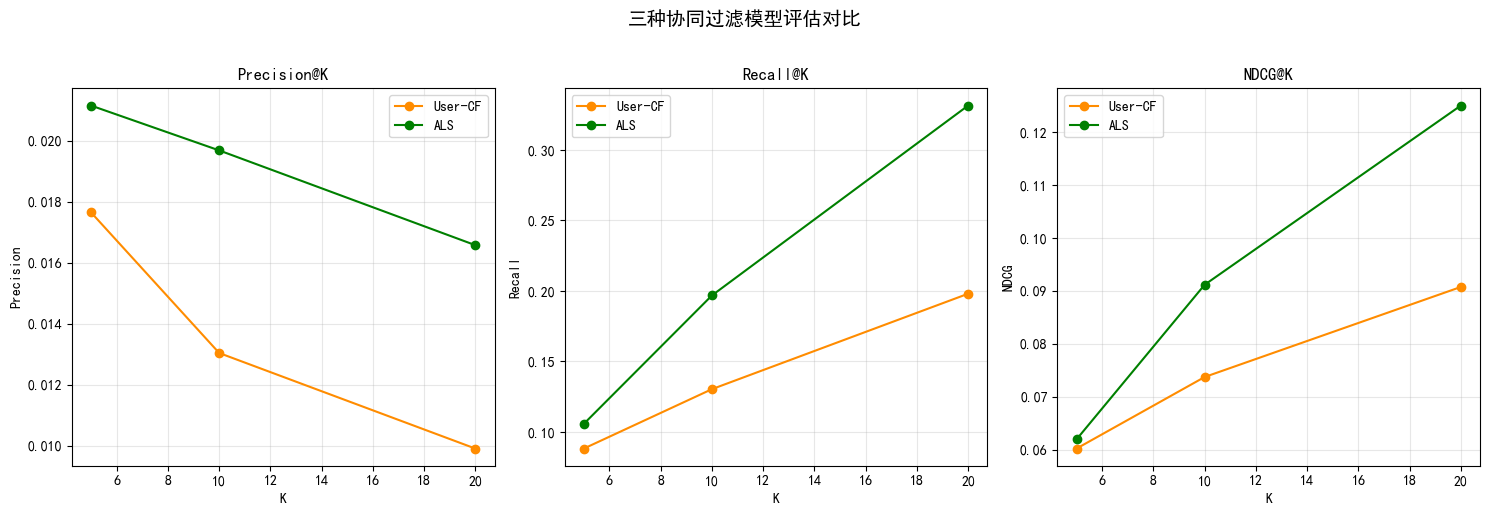


── 评估结果汇总（@K=10）──
         Precision  Recall    NDCG
User-CF     0.0130  0.1304  0.0737
ALS         0.0197  0.1968  0.0912


In [14]:
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics   = ['Precision', 'Recall', 'NDCG']
colors    = {'User-CF': 'darkorange', 'ALS': 'green'}

eval_dict = {
    'User-CF': user_cf_eval,
    'ALS':     als_eval
}

for ax, metric in zip(axes, metrics):
    for model_name, eval_df in eval_dict.items():
        ax.plot(
            eval_df.index,
            eval_df[metric],
            marker='o',
            label=model_name,
            color=colors[model_name]
        )
    ax.set_title(f'{metric}@K')
    ax.set_xlabel('K')
    ax.set_ylabel(metric)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('两种协同过滤模型评估对比', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# 汇总表
print('\n── 评估结果汇总（@K=10）──')
summary = pd.DataFrame({
    name: df.loc[10]
    for name, df in eval_dict.items()
}).T.round(4)
print(summary)

In [17]:
# ── 保存 Step 3 最终结果 ──
recommendation_artifacts = {
    'user_cf_recs':  user_cf_recs,
    'als_recs':      als_recs,
    'user_cf_eval':  user_cf_eval,
    'als_eval':      als_eval
}

with open(BASE / 'recommendation_artifacts.pkl', 'wb') as f:
    pickle.dump(recommendation_artifacts, f)

print('✅ Step 3 完成，结果已保存')
print()
print('── @K=10 最终汇总 ──')
print(summary)

✅ Step 3 完成，结果已保存

── @K=10 最终汇总 ──
         Precision  Recall    NDCG
User-CF     0.0130  0.1304  0.0737
ALS         0.0197  0.1968  0.0912
